In [3]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import mytools
from scipy.optimize import curve_fit

In [36]:
data_dir = '/Users/mghrear/data/ML_data/2019_pass2/ensemble_results/inference/unscaled/'

In [72]:
fit_ranges = {
    1: (1005, 1035),
    2: (1005, 1035),
    3: (1005, 1035),
    4: (1005, 1030),
    5: (1005, 1035),
    6: (1005, 1035),
    7: (1005, 1035),
    8: (1005, 1035),
    9: (1005, 1035),
    10: (1005, 1035),
    11: (1005, 1035),
    12: (1005, 1035),
    13: (1005, 1035),
    14: (1005, 1035),
    15: (1005, 1035),
    16: (1005, 1035),
    17: (1005, 1035),
    18: (1005, 1035),
    19: (1005, 1035),
    20: (1005, 1035),
    21: (1005, 1035),
    22: (1005, 1035),
    23: (1005, 1035),
    24: (1005, 1035),
    25: (1005, 1035),
    26: (1005, 1035),
    27: (1005, 1035),
    28: (1005, 1035),
    29: (1005, 1035),
    30: (1005, 1035),
    31: (1005, 1035),
    32: (1005, 1035),
    33: (1005, 1035),
    34: (1005, 1035),
    35: (1005, 1035),
    36: (1005, 1035),
    37: (1005, 1035),
    38: (1005, 1035),
    39: (1005, 1035),
    40: (1005, 1035),
    41: (1005, 1035),
    42: (1005, 1035),
    43: (1005, 1035),
    44: (1005, 1035),
    45: (1005, 1035),
    46: (1005, 1035),
    47: (1005, 1035),
    48: (1005, 1035),
    49: (1005, 1035),
    50: (1005, 1035),
    51: (1005, 1035),
    52: (1005, 1035),
    53: (1005, 1035),
    54: (1005, 1035),
    55: (1005, 1035),
    56: (1005, 1035),
    57: (1005, 1035),
    58: (1000, 1035),
    59: (1005, 1035),
    60: (1005, 1035),
    61: (1005, 1035),
    62: (1005, 1035),
    63: (1005, 1035),
    64: (1005, 1035),
    65: (1005, 1035),
    66: (1005, 1035),
    67: (1005, 1035),
    68: (1005, 1035),
    69: (1005, 1035),
    70: (1005, 1035),
    71: (1005, 1035),
    72: (1005, 1035),
    73: (1005, 1035),
    74: (1005, 1035),
    75: (1005, 1035),
    76: (1005, 1035),
    77: (1005, 1035),
    78: (1005, 1035),
    79: (1005, 1035),
    80: (1005, 1035),
    81: (1005, 1035),
    82: (1005, 1035),
    83: (1005, 1035),
    84: (1005, 1035),
    85: (1005, 1035),
    86: (1005, 1035),
    87: (1005, 1035),
    88: (1005, 1035),
    89: (1005, 1035),
    90: (1005, 1035),
    91: (1005, 1035),
    92: (1005, 1035),
    93: (1005, 1035),
    94: (1005, 1035),
    95: (1005, 1035),
    96: (1005, 1035),
    97: (1005, 1035),
    98: (1005, 1035),
    99: (1005, 1035),
    100: (1005, 1035),
    }

In [96]:
run_number = 5
num = 10000

df = pd.read_pickle(data_dir + f'2019_pass2_data_full_run{run_number}.pk')
df.InvM = df.InvM * 1000
df_cut = df.nlargest(num, 'ANN')

In [97]:
df_cut

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,pos_Px,pos_Py,pos_Pz,ele_Px,ele_Py,ele_Pz,ANN,InvM
1617888,0.422270,0.649853,191.709229,29.653910,1449.173706,74.629814,-39.801090,1448.616943,-0.106377,-0.053285,1.701198,0.542575,0.049312,2.715078,1.000000,1165.376995
1337203,3.204153,0.262887,204.782043,28.028913,1449.394531,108.444710,-66.498169,1449.064331,-0.110275,-0.060612,1.177481,0.622304,0.055774,3.006232,1.000000,1237.626141
1423276,1.343465,0.344861,176.270981,-35.751854,1449.285522,113.524200,30.628891,1448.728516,-0.065647,0.037622,1.555425,0.458489,-0.062411,2.422008,1.000000,1110.952879
1606479,1.445359,0.777815,199.729248,54.311699,1449.617676,84.768356,-54.455479,1448.729004,-0.091263,-0.066342,1.888922,0.516033,0.106190,2.532195,1.000000,1152.498423
806500,3.642859,0.231443,197.139313,33.779518,1449.394531,71.191788,-47.880741,1448.616943,-0.139511,-0.045212,1.214292,0.619114,0.074684,3.075969,1.000000,1256.140306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207469,0.000000,0.345294,-9999.000000,-9999.000000,-9999.000000,263.469574,-78.216049,1450.379395,0.189727,-0.119221,2.121425,-0.003055,0.122398,1.696657,0.999603,1037.220092
1202691,0.728513,0.661112,-168.483643,84.443787,1450.272339,250.538269,-35.155060,1449.834595,0.182264,-0.051143,2.207355,-0.032944,0.124121,1.964163,0.999603,1026.262478
1582330,0.000000,0.266771,-9999.000000,-9999.000000,-9999.000000,314.676025,65.301300,1450.695190,0.286268,0.104697,2.078024,0.023662,-0.021692,1.022240,0.999603,1063.166390
766764,0.000000,0.278182,-9999.000000,-9999.000000,-9999.000000,275.454010,55.741383,1450.268799,0.260802,0.084481,2.249147,0.086037,-0.117004,1.732447,0.999603,1025.259086


Signal yield : 2575.0 ± 610.5
Mean         : 1028.656 ± 1.079 MeV
Sigma        : 11.819 ± 1.815 MeV
χ²/ndf       : 38.6 / 25 = 1.54  (p = 0.040)


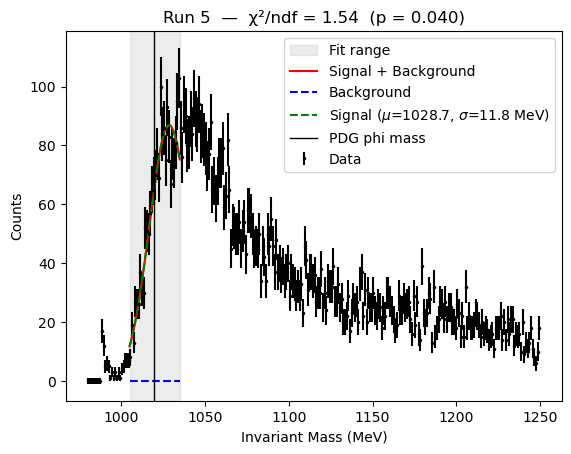

In [98]:

m_phi = 1019.461
m_lo, m_hi = fit_ranges[run_number]  # fit window in MeV
bin_width = 1            # MeV per bin

bins = np.arange(m_lo, m_hi + bin_width, bin_width)
counts, edges = np.histogram(df_cut.InvM, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
errors = np.where(counts > 0, np.sqrt(counts), 1)  # Poisson errors, floor at 1

def signal(m, n_sig, mu, sigma):
    return n_sig / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((m - mu) / sigma) ** 2)

def background(m, n_bkg, lam):
    return n_bkg * lam * np.exp(-lam * (m - m_lo))

def model(m, n_sig, mu, sigma, n_bkg, lam):
    return signal(m, n_sig, mu, sigma) + background(m, n_bkg, lam)

p0     = [1000,  m_phi, 5,   counts.sum(), 1/30]
bounds = ([0,    1000,  0.1, 0,            0   ],
          [np.inf, 1060, 50, np.inf,       1   ])

popt, pcov = curve_fit(model, centers, counts, p0=p0, sigma=errors,
                       absolute_sigma=True, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
n_sig, mu, sigma, n_bkg, lam = popt
n_sig_err, mu_err, sigma_err = perr[:3]

chi2 = np.sum(((counts - model(centers, *popt)) / errors) ** 2)
ndf  = len(counts) - len(popt)
from scipy.stats import chi2 as chi2_dist
pval = chi2_dist.sf(chi2, ndf)
print(f"Signal yield : {n_sig:.1f} ± {n_sig_err:.1f}")
print(f"Mean         : {mu:.3f} ± {mu_err:.3f} MeV")
print(f"Sigma        : {sigma:.3f} ± {sigma_err:.3f} MeV")
print(f"χ²/ndf       : {chi2:.1f} / {ndf} = {chi2/ndf:.2f}  (p = {pval:.3f})")

# Full-range histogram
full_bins = np.arange(980, 1251, bin_width)
full_counts, full_edges = np.histogram(df_cut.InvM, bins=full_bins)
full_centers = 0.5 * (full_edges[:-1] + full_edges[1:])
full_errors = np.where(full_counts > 0, np.sqrt(full_counts), 1)

m_fine = np.linspace(m_lo, m_hi, 1000)
fig, ax = plt.subplots()
ax.errorbar(full_centers, full_counts, yerr=full_errors, fmt='k.', ms=3, label='Data')
ax.axvspan(m_lo, m_hi, color='grey', alpha=0.15, label='Fit range')
ax.plot(m_fine, model(m_fine, *popt),             'r-',  label='Signal + Background')
ax.plot(m_fine, background(m_fine, n_bkg, lam),   'b--', label='Background')
ax.plot(m_fine, signal(m_fine, n_sig, mu, sigma),  'g--', label=f'Signal ($\\mu$={mu:.1f}, $\\sigma$={sigma:.1f} MeV)')
ax.axvline(m_phi, color='k', linewidth=1, label='PDG phi mass')
#ax.axvline(1050.0, color='r', linewidth=1, label='Fake mass')
ax.set_title(f'Run {run_number}  —  χ²/ndf = {chi2/ndf:.2f}  (p = {pval:.3f})')
ax.set_xlabel('Invariant Mass (MeV)')
ax.set_ylabel('Counts')
ax.legend()
plt.show()

In [85]:
QualCuts = {
    'pos_E_Ecal_low': 0.6,
    'pos_Px_low': -0.06,
    'ele_Ecal_z_low': 1448.6,
    'ele_Ecal_y_low': -85.0,
    'ele_Ecal_y_high': 85.0,
}

Signal yield : 115043.3 ± 55276.1
Mean         : 1000.791 ± 17.333 MeV
Sigma        : 40.555 ± 14.698 MeV
χ²/ndf       : 19.8 / 25 = 0.79  (p = 0.758)


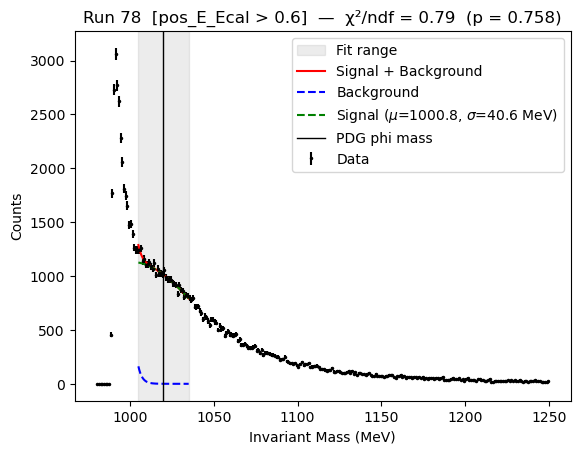

In [ ]:
df_qual = df.loc[df.pos_E_Ecal > QualCuts['pos_E_Ecal_low']]
df_qual_cut = df_qual.nlargest(num, 'ANN')

m_lo, m_hi = fit_ranges[run_number]
bin_width = 1

bins = np.arange(m_lo, m_hi + bin_width, bin_width)
counts_q, edges_q = np.histogram(df_qual_cut.InvM, bins=bins)
centers_q = 0.5 * (edges_q[:-1] + edges_q[1:])
errors_q = np.where(counts_q > 0, np.sqrt(counts_q), 1)

popt_q, pcov_q = curve_fit(model, centers_q, counts_q, p0=p0, sigma=errors_q,
                            absolute_sigma=True, bounds=bounds)
perr_q = np.sqrt(np.diag(pcov_q))
n_sig_q, mu_q, sigma_q, n_bkg_q, lam_q = popt_q
n_sig_err_q, mu_err_q, sigma_err_q = perr_q[:3]

chi2_q = np.sum(((counts_q - model(centers_q, *popt_q)) / errors_q) ** 2)
ndf_q  = len(counts_q) - len(popt_q)
from scipy.stats import chi2 as chi2_dist
pval_q = chi2_dist.sf(chi2_q, ndf_q)
print(f"Signal yield : {n_sig_q:.1f} ± {n_sig_err_q:.1f}")
print(f"Mean         : {mu_q:.3f} ± {mu_err_q:.3f} MeV")
print(f"Sigma        : {sigma_q:.3f} ± {sigma_err_q:.3f} MeV")
print(f"χ²/ndf       : {chi2_q:.1f} / {ndf_q} = {chi2_q/ndf_q:.2f}  (p = {pval_q:.3f})")

full_bins = np.arange(980, 1251, bin_width)
full_counts_q, full_edges_q = np.histogram(df_qual_cut.InvM, bins=full_bins)
full_centers_q = 0.5 * (full_edges_q[:-1] + full_edges_q[1:])
full_errors_q = np.where(full_counts_q > 0, np.sqrt(full_counts_q), 1)

m_fine = np.linspace(m_lo, m_hi, 1000)
fig, ax = plt.subplots()
ax.errorbar(full_centers_q, full_counts_q, yerr=full_errors_q, fmt='k.', ms=3, label='Data')
ax.axvspan(m_lo, m_hi, color='grey', alpha=0.15, label='Fit range')
ax.plot(m_fine, model(m_fine, *popt_q),              'r-',  label='Signal + Background')
ax.plot(m_fine, background(m_fine, n_bkg_q, lam_q),  'b--', label='Background')
ax.plot(m_fine, signal(m_fine, n_sig_q, mu_q, sigma_q), 'g--', label=f'Signal ($\\mu$={mu_q:.1f}, $\\sigma$={sigma_q:.1f} MeV)')
ax.axvline(m_phi, color='k', linewidth=1, label='PDG phi mass')
ax.set_title(f'Run {run_number}  [pos_E_Ecal > {QualCuts["pos_E_Ecal_low"]}]  —  χ²/ndf = {chi2_q/ndf_q:.2f}  (p = {pval_q:.3f})')
ax.set_xlabel('Invariant Mass (MeV)')
ax.set_ylabel('Counts')
ax.legend()
plt.show()